ACTIVIDAD 2

BEATRIZ ABIGAIL TRUJILLO MARTINEZ

a) Implementar una función que calcule:

Promedio de ventas (Average_Sales).
Venta máxima (Max_Sales).
Venta mínima (Min_Sales).
b) Agrupar y aplicar la función usando groupby para agrupar los datos por mes y región geográfica. Aplicar la función personalizada sobre los grupos.

c) Exportar los resultados, guardando las métricas calculadas en un archivo CSV llamado sales_metrics_by_region.csv.

d) Realizar un informe basado en impresiones de pantalla donde expliques lo realizado y adjunta tu archivo CSV.

In [1]:
## Base de datos
import pandas as pd

# Cargar los datos
ventas = pd.read_csv('sales_data_2023.csv')

# Para visualizar las primeras 5 filas 
print ("Ventas",ventas.head())


Ventas    Sale_ID  Customer_ID  Sale_Amount   Sale_Date Geography
0        1           38        31.11  2023-05-03      West
1        2           18       191.54  2023-03-06     South
2        3          197       283.74  2023-06-23      East
3        4          185       367.13  2023-02-09     South
4        5          171       188.52  2023-12-25     South


In [2]:
# Revisar columnas y tipos de datos
#Nombre de columnas
print("Columnas de ventas:",ventas.columns.tolist())

#Tipo de datos
print ("\nTipos de datos = ventas:")
print (ventas.dtypes)

Columnas de ventas: ['Sale_ID', 'Customer_ID', 'Sale_Amount', 'Sale_Date', 'Geography']

Tipos de datos = ventas:
Sale_ID          int64
Customer_ID      int64
Sale_Amount    float64
Sale_Date       object
Geography       object
dtype: object


In [3]:
# Tipo de datos de la base de datos junto con nulos
print(ventas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      1000 non-null   int64  
 1   Customer_ID  1000 non-null   int64  
 2   Sale_Amount  1000 non-null   float64
 3   Sale_Date    1000 non-null   object 
 4   Geography    1000 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB
None


In [4]:
# Datos nulos
print("Datos nulos en ventas:",ventas.isnull().sum())
print("Datos nulos en el data frame de ventas:",ventas.isna().sum().sum())

Datos nulos en ventas: Sale_ID        0
Customer_ID    0
Sale_Amount    0
Sale_Date      0
Geography      0
dtype: int64
Datos nulos en el data frame de ventas: 0


In [5]:
#Geographic conocer que categorias contiene
# Devuelve un conteo de cada valor único
conteo = ventas["Geography"].value_counts()
print(f"La columna tiene {conteo} categorías únicas.")

La columna tiene Geography
North    262
West     259
South    240
East     239
Name: count, dtype: int64 categorías únicas.


In [6]:
#Cambiar el tipo ed dato de Geography
ventas["Geography"] = ventas["Geography"].astype("category")

#Tipo de dato y categorias
print(f"Tipo de dato: {ventas['Geography'].dtype}")
print(f"Categorías disponibles: {ventas['Geography'].cat.categories.tolist()}")

Tipo de dato: category
Categorías disponibles: ['East', 'North', 'South', 'West']


In [7]:
# Filas que contienen algo que NO es un número (dígito o punto)
# El patrón r'[^\d\.]' busca cualquier carácter que no sea 0-9 ni punto
sospechosos = ventas[ventas['Sale_Amount'].astype(str).str.contains(r'[^\d\.]', na=False)]

# Mostrar los valores únicos de esas filas para ver qué caracteres son
print("Los sospechosos son",sospechosos['Sale_Amount'].unique())

Los sospechosos son []


In [8]:
#Transformar el campo de sale_amount
ventas["Sale_Amount"]=(ventas["Sale_Amount"].astype(str).str.replace("$","",regex=False))
ventas["Sale_Amount"]=pd.to_numeric(ventas["Sale_Amount"],errors="coerce")
print(ventas["Sale_Amount"].dtype)
print(ventas["Sale_Amount"].describe())

float64
count    1000.000000
mean      253.532920
std       142.291244
min        10.510000
25%       124.297500
50%       258.190000
75%       373.130000
max       500.740000
Name: Sale_Amount, dtype: float64


In [9]:
# Cambio de tipo de dato
# Dato que el campo de sale_date se encuentra incorrecto el tipo de dato se decide cambiar de formato
#Fecha
ventas["Sale_Date"]=pd.to_datetime(ventas["Sale_Date"],format="mixed",dayfirst=False,errors="coerce")

print(ventas["Sale_Date"].dtype)
print(ventas["Sale_Date"].isnull().sum())
print(ventas["Sale_Date"].min(), "_",
      ventas["Sale_Date"].max())

datetime64[ns]
0
2023-01-01 00:00:00 _ 2023-12-31 00:00:00


In [10]:
#Revisar si los campos se convirtieron en el tipo de campo deseado
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Sale_ID      1000 non-null   int64         
 1   Customer_ID  1000 non-null   int64         
 2   Sale_Amount  1000 non-null   float64       
 3   Sale_Date    1000 non-null   datetime64[ns]
 4   Geography    1000 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 32.6 KB


In [11]:
# Ver cuántas filas duplicadas existen
total_duplicados = ventas.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

# ver cuáles son esas filas
filas_duplicadas = ventas[ventas.duplicated()]
print(filas_duplicadas)

Total de filas duplicadas: 0
Empty DataFrame
Columns: [Sale_ID, Customer_ID, Sale_Amount, Sale_Date, Geography]
Index: []


In [12]:
#Detectar outliers Sale_Amount
Q1 = ventas["Sale_Amount"].quantile(0.25)
Q3 = ventas["Sale_Amount"].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
    
# Detectar los outliers
outliers = ventas[(ventas["Sale_Amount"] < limite_inferior) | (ventas["Sale_Amount"] > limite_superior)]

print(f"Se encontraron {len(outliers)} valores atípicos.")

Se encontraron 0 valores atípicos.


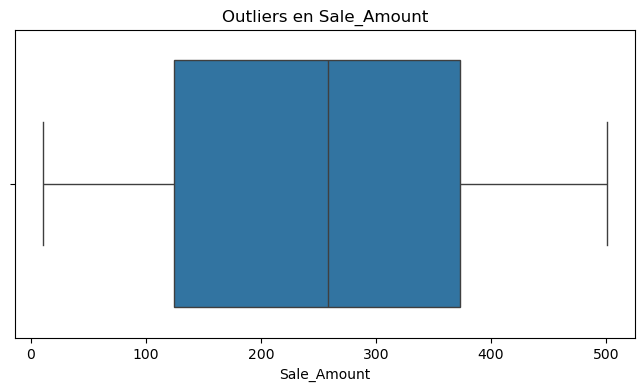

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x=ventas['Sale_Amount'])
plt.title('Outliers en Sale_Amount')
plt.show()

In [14]:
#Defino la clase
class AnalisisVentas:
    def __init__(self,ventas): 
        self.ventas=ventas
    
    
# Calcular promedio
    def promedio(self):
        promedio = self.ventas.mean()
        print(f'Promedio de las ventas: {promedio}')
        return promedio

# Calcular máximos
    def venta_maxima(self):
        maxima = self.ventas.max()
        print(f'Venta máxima: {maxima}')
        return maxima

# Calcular mínimos
    def venta_minima(self):
        minima = self.ventas.min()
        print(f'Venta mínima: {minima}')
        return minima

In [15]:
# Conocer el promedio general de las ventas
analisis_general = AnalisisVentas(
    ventas['Sale_Amount']
)
#Promedio
promedio = analisis_general.promedio()

#Valor maximo
maximo = analisis_general.venta_maxima()

#Valor minimo
minimo = analisis_general.venta_minima()

Promedio de las ventas: 253.53292000000002
Venta máxima: 500.74
Venta mínima: 10.51


In [16]:
#Agrupación de los datos de promedio, maximo y minimo de las ventas generales para poder graficar
resumen = pd.DataFrame({
    'Métrica': ['Promedio', 'Máximo', 'Mínimo'],
    'Venta': [promedio, maximo, minimo]
})

resumen

,Métrica,Venta
0,Promedio,253.53292
1,Máximo,500.74000
2,Mínimo,10.51000


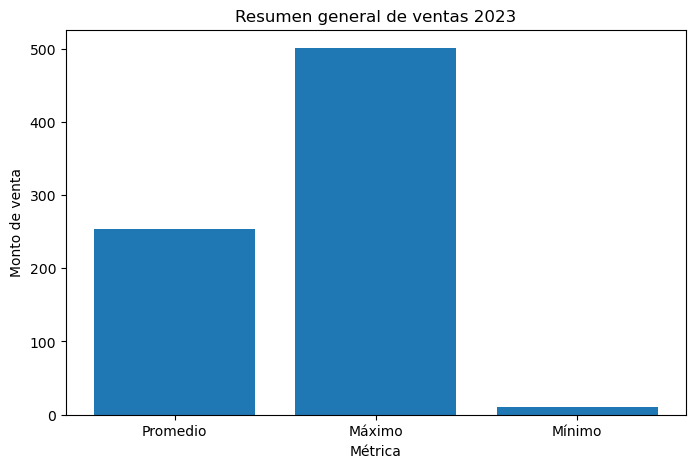

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.bar(
    resumen['Métrica'],
    resumen['Venta']
)

plt.title('Resumen general de ventas 2023')

plt.xlabel('Métrica')

plt.ylabel('Monto de venta')

plt.show()

Dado que ahora se quiere conocer las ventas agrupando por mes y región se realiza lo siguiente

In [18]:
#Convertir Sale_Date en mes para poder realizar la agrupación por mes
ventas['Month'] = ventas['Sale_Date'].dt.month
print(ventas)

     Sale_ID  Customer_ID  Sale_Amount  Sale_Date Geography  Month
0          1           38        31.11 2023-05-03      West      5
1          2           18       191.54 2023-03-06     South      3
2          3          197       283.74 2023-06-23      East      6
3          4          185       367.13 2023-02-09     South      2
4          5          171       188.52 2023-12-25     South     12
..       ...          ...          ...        ...       ...    ...
995      996          181        74.20 2023-08-26      East      8
996      997          157       215.66 2023-05-07      West      5
997      998          273       266.32 2023-01-14      West      1
998      999           43       252.43 2023-06-17     South      6
999     1000          291        23.16 2023-04-10     South      4

[1000 rows x 6 columns]


In [19]:
#Conocer la distribución de ventas por región
ventas['Geography'].value_counts()

Geography
North    262
West     259
South    240
East     239
Name: count, dtype: int64

In [20]:
#Conocer las ventas por mes, para asegurarnos que tengan datos todos los meses
ventas['Month'].value_counts().sort_index()

Month
1      81
2      80
3     107
4      74
5      90
6      79
7      74
8      84
9      90
10     85
11     65
12     91
Name: count, dtype: int64

In [21]:
#Con lo anterior es necesario crear una función para la agrupación
def calcular_metricas(grupo):
    analisis = AnalisisVentas( #ocupamos la funcion anteriormente utilizada)
        grupo['Sale_Amount'] # se agrupa por las ventas
    )
    return pd.Series({  # se retorna una lista
        'Promedio_Ventas': analisis.promedio(), # promedio por ventas
        'Maxima_Venta': analisis.venta_maxima(), # valor maximo de ventas

        'Minima_Venta': analisis.venta_minima() # valor minimo de ventas

    })


In [22]:
#Agrupamos por mes y región
metricas_region = ventas.groupby(
    ['Month','Geography']
).apply(calcular_metricas)


Promedio de las ventas: 249.04705882352943
Venta máxima: 493.77
Venta mínima: 33.78
Promedio de las ventas: 221.95551724137934
Venta máxima: 447.02
Venta mínima: 32.22
Promedio de las ventas: 258.73739130434785
Venta máxima: 495.99
Venta mínima: 24.14
Promedio de las ventas: 298.725
Venta máxima: 492.73
Venta mínima: 44.54
Promedio de las ventas: 354.322
Venta máxima: 497.01
Venta mínima: 66.37
Promedio de las ventas: 300.801875
Venta máxima: 466.96
Venta mínima: 109.12
Promedio de las ventas: 263.53625000000005
Venta máxima: 483.74
Venta mínima: 23.07
Promedio de las ventas: 257.3355
Venta máxima: 469.64
Venta mínima: 12.21
Promedio de las ventas: 276.014
Venta máxima: 490.34
Venta mínima: 16.28
Promedio de las ventas: 210.3914705882353
Venta máxima: 456.08
Venta mínima: 25.0
Promedio de las ventas: 245.3176923076923
Venta máxima: 499.08
Venta mínima: 16.31
Promedio de las ventas: 281.5048148148148
Venta máxima: 498.47
Venta mínima: 15.5
Promedio de las ventas: 201.238
Venta máxima: 5

C:\Users\abiga\AppData\Local\Temp\ipykernel_16576\107346681.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metricas_region = ventas.groupby(
C:\Users\abiga\AppData\Local\Temp\ipykernel_16576\107346681.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(calcular_metricas)


In [23]:
print(metricas_region)

                 Promedio_Ventas  Maxima_Venta  Minima_Venta
Month Geography                                             
1     East            249.047059        493.77         33.78
      North           221.955517        447.02         32.22
      South           258.737391        495.99         24.14
      West            298.725000        492.73         44.54
2     East            354.322000        497.01         66.37
      North           300.801875        466.96        109.12
      South           263.536250        483.74         23.07
      West            257.335500        469.64         12.21
3     East            276.014000        490.34         16.28
      North           210.391471        456.08         25.00
      South           245.317692        499.08         16.31
      West            281.504815        498.47         15.50
4     East            201.238000        500.28         26.98
      North           209.817778        496.67         11.39
      South           27

In [24]:
metricas_region = metricas_region.reset_index()
print(metricas_region)

    Month Geography  Promedio_Ventas  Maxima_Venta  Minima_Venta
0       1      East       249.047059        493.77         33.78
1       1     North       221.955517        447.02         32.22
2       1     South       258.737391        495.99         24.14
3       1      West       298.725000        492.73         44.54
4       2      East       354.322000        497.01         66.37
5       2     North       300.801875        466.96        109.12
6       2     South       263.536250        483.74         23.07
7       2      West       257.335500        469.64         12.21
8       3      East       276.014000        490.34         16.28
9       3     North       210.391471        456.08         25.00
10      3     South       245.317692        499.08         16.31
11      3      West       281.504815        498.47         15.50
12      4      East       201.238000        500.28         26.98
13      4     North       209.817778        496.67         11.39
14      4     South      

C:\Users\abiga\AppData\Local\Temp\ipykernel_16576\1897520021.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grafico=metricas_region.groupby('Geography')['Promedio_Ventas'].mean().plot(


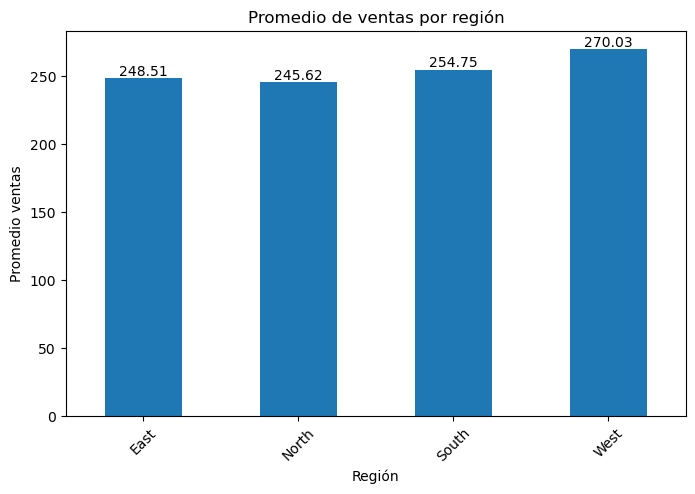

In [25]:
#Grafico de promedio de ventas por región
import matplotlib.pyplot as plt

grafico=metricas_region.groupby('Geography')['Promedio_Ventas'].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Promedio de ventas por región')
plt.xlabel('Región')
plt.ylabel('Promedio ventas')
plt.xticks(rotation=45)
# Agregar etiquetas de valores
plt.bar_label(grafico.containers[0], fmt='%.2f')

plt.show()




C:\Users\abiga\AppData\Local\Temp\ipykernel_16576\2129925697.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grafico = metricas_region.groupby('Geography').agg({


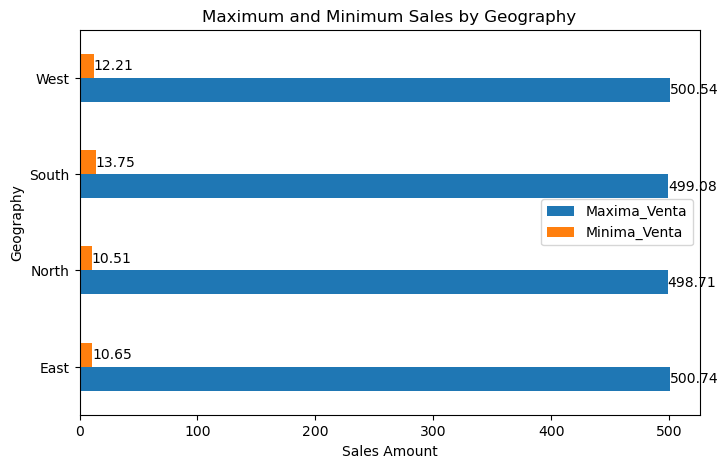

In [27]:
grafico = metricas_region.groupby('Geography').agg({
    'Maxima_Venta':'max',
    'Minima_Venta':'min'
}).plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Maximum and Minimum Sales by Geography')
plt.xlabel('Sales Amount')
plt.ylabel('Geography')

for contenedor in grafico.containers:
    plt.bar_label(contenedor, fmt='%.2f')

plt.show()

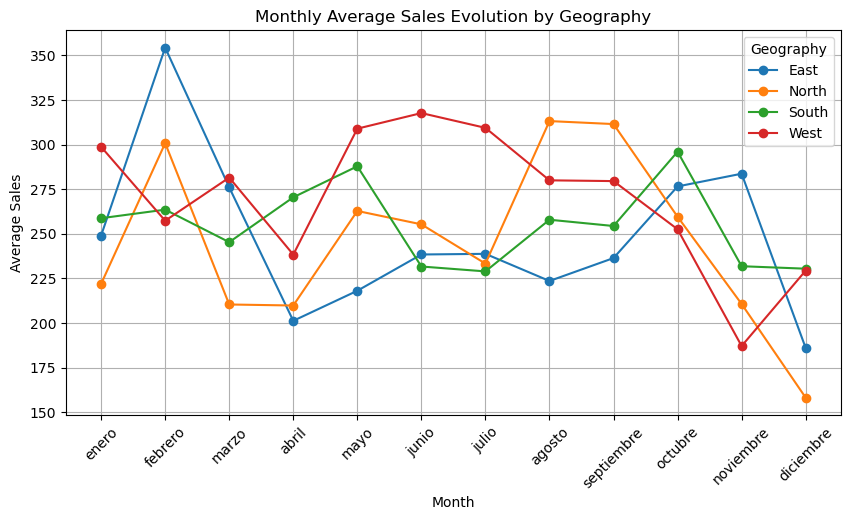

In [ ]:
import calendar
#Promedio de ventas por mes y región
grafico = metricas_region.pivot(
    index='Month',
    columns='Geography',
    values='Promedio_Ventas'
).plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

# Cambiar números por nombres de meses
plt.xticks(
    ticks=range(1,13),
    labels=[calendar.month_name[i] for i in range(1,13)],
    rotation=45
)

plt.title('Monthly Average Sales Evolution by Geography')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.grid()
plt.show()

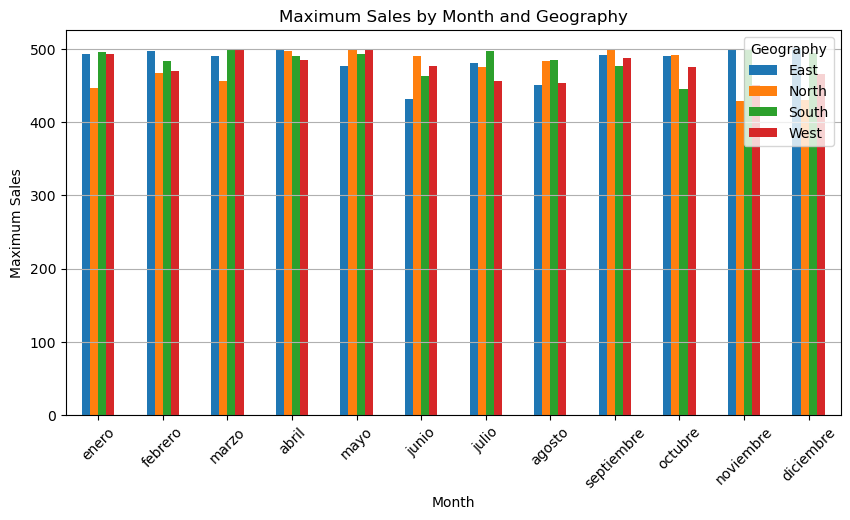

In [32]:
#Maxima
import calendar

grafico = metricas_region.pivot(
    index='Month',
    columns='Geography',
    values='Maxima_Venta'
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Maximum Sales by Month and Geography')
plt.xlabel('Month')
plt.ylabel('Maximum Sales')

plt.xticks(
    ticks=range(12),
    labels=[calendar.month_name[i] for i in range(1,13)],
    rotation=45
)

plt.legend(title='Geography')
plt.grid(axis='y')

plt.show()

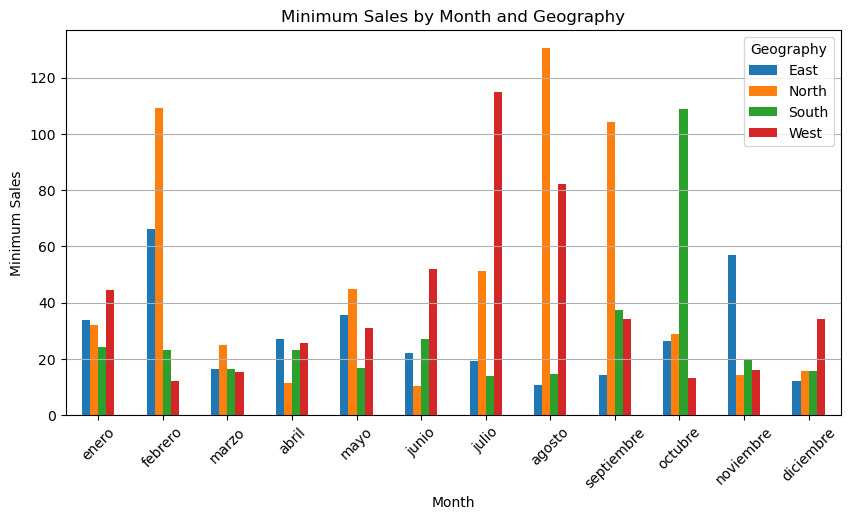

In [33]:
#Minimas
grafico = metricas_region.pivot(
    index='Month',
    columns='Geography',
    values='Minima_Venta'
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Minimum Sales by Month and Geography')
plt.xlabel('Month')
plt.ylabel('Minimum Sales')

plt.xticks(
    ticks=range(12),
    labels=[calendar.month_name[i] for i in range(1,13)],
    rotation=45
)

plt.legend(title='Geography')
plt.grid(axis='y')

plt.show()

In [34]:
metricas_region = ventas.groupby(
    ['Month', 'Geography']
).apply(calcular_metricas)

# Convertir los índices de agrupación en columnas
metricas_region = metricas_region.reset_index()

print(metricas_region)

Promedio de las ventas: 249.04705882352943
Venta máxima: 493.77
Venta mínima: 33.78
Promedio de las ventas: 221.95551724137934
Venta máxima: 447.02
Venta mínima: 32.22
Promedio de las ventas: 258.73739130434785
Venta máxima: 495.99
Venta mínima: 24.14
Promedio de las ventas: 298.725
Venta máxima: 492.73
Venta mínima: 44.54
Promedio de las ventas: 354.322
Venta máxima: 497.01
Venta mínima: 66.37
Promedio de las ventas: 300.801875
Venta máxima: 466.96
Venta mínima: 109.12
Promedio de las ventas: 263.53625000000005
Venta máxima: 483.74
Venta mínima: 23.07
Promedio de las ventas: 257.3355
Venta máxima: 469.64
Venta mínima: 12.21
Promedio de las ventas: 276.014
Venta máxima: 490.34
Venta mínima: 16.28
Promedio de las ventas: 210.3914705882353
Venta máxima: 456.08
Venta mínima: 25.0
Promedio de las ventas: 245.3176923076923
Venta máxima: 499.08
Venta mínima: 16.31
Promedio de las ventas: 281.5048148148148
Venta máxima: 498.47
Venta mínima: 15.5
Promedio de las ventas: 201.238
Venta máxima: 5

C:\Users\abiga\AppData\Local\Temp\ipykernel_16576\3044948252.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metricas_region = ventas.groupby(
C:\Users\abiga\AppData\Local\Temp\ipykernel_16576\3044948252.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(calcular_metricas)


In [36]:
metricas_region.to_csv(
    'sales_metrics_by_region.csv',
    index=False
)
print("Archivo exportado correctamente")

Archivo exportado correctamente
